In [19]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, roc_auc_score
import time
import gc
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
import time

# from sklearnex import patch_sklearn
# patch_sklearn()  # patches scikit-learn algorithms

# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
import os
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET
ID = cfg.ID
SUB_PATH = cfg.SUB_PATH
SUBMIT_PROBABILITIES = cfg.SUBMIT_PROBABILITIES

from src.optuna_utils import run_optuna
from src.evaluation_utils import evaluate_metric, evaluate_model
from src.visualization_utils import plot_feature_importance, plot_learning_curve, shap_summary
from src.experiment_tracker import ExperimentTracker


# -------------------------------------------------------

# model imports
from src.training_utils import train_xgb_final



# -------------------------------
# Load Data
# -------------------------------
X_train, X_test, y_train, y_test = load_data("encoded")
# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

# Ensure y is numpy array
y_train_numeric = np.array(y_train_numeric)
y_test_numeric = np.array(y_test_numeric) if y_test_numeric is not None else None

sys.path contains: /home/ismail/x42
Number of classes: 2
X_train shape: (300000, 116)
X_test shape: (200000, 116)
y_train shape: (300000,)
y_test labels are not available


In [ ]:
# from sklearn.model_selection import train_test_split

# X_train, _, y_train_numeric, _ = train_test_split(
#     X_train,
#     y_train_numeric,
#     test_size=0.95,              # keep only 10%
#     random_state=RANDOM_STATE,
#     stratify=y_train_numeric    # IMPORTANT: preserves class balance
# )

# print("Original:", X_train.shape)
# print("Sample:", X_train.shape)

# X_test = X_test.sample(
#     frac=0.07,
#     random_state=RANDOM_STATE
# )

Original: (15000, 116)
Sample: (15000, 116)


In [ ]:
from src.data_splitter import DataSplitter

# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=42,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy" # folds_xgb.npy?
)

folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


✅ Generated 5 folds for current dataset
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 15000
Total folds: 5

Fold 0: Train size=12000, Val size=3000
Fold 1: Train size=12000, Val size=3000
Fold 2: Train size=12000, Val size=3000
Fold 3: Train size=12000, Val size=3000
Fold 4: Train size=12000, Val size=3000


# Optuna

In [14]:
import xgboost as xgb
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import gc
from src.data_splitter import DataSplitter
from optuna.integration import XGBoostPruningCallback

# -------------------------------
# XGBoost Objective for Optuna
# -------------------------------
def objective(trial):
    num_classes = len(np.unique(y_train_numeric))
    metric_name = cfg.LIB_PARAMS["xgboost"]["eval_metric"]
    maximize_metric = cfg.MAXIMIZE_METRIC





    # -------------------------------
    # Suggest hyperparameters
    # -------------------------------
    param = {
        "objective": cfg.LIB_PARAMS["xgboost"]["objective"],
        "eval_metric": metric_name,
        "booster": "gbtree",
        "tree_method": "hist",  # "gpu_hist" if using GPU
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 0.5),
        "seed": getattr(cfg, "RANDOM_STATE", 42),








        # 'grow_policy': trial.suggest_categorical('grow_policy', ["depthwise", "lossguide"]),
        # 'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        # 'device': "cuda"
    }

    if num_classes > 2:
        param["num_class"] = num_classes

    # -------------------------------
    # Compute class weights if multiclass
    # -------------------------------
    if cfg.TASK.lower() == "multiclass":
        classes = np.unique(y_train_numeric)
        class_weights = compute_class_weight("balanced", classes=classes, y=y_train_numeric)
        sample_weights = np.array([class_weights[int(c)] for c in y_train_numeric])
    elif cfg.TASK.lower() == "binary":
        sample_weights = None


    oof_preds = np.zeros((len(X_train), num_classes)) if num_classes > 2 else np.zeros(len(X_train))
    all_fold_evals = []
    fold_results = []
    auc_scores, logloss_scores = [], []

    for n_fold, (train_idx, valid_idx) in enumerate(folds, start=1):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]
        w_tr = sample_weights[train_idx] if sample_weights is not None else None

        dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr)
        dvalid = xgb.DMatrix(X_val, label=y_val)

        evals_result = {}

        model = xgb.train(
            params=param,
            dtrain=dtrain,
            num_boost_round=cfg.NUM_BOOST_ROUND,
            evals=[(dtrain, "train"), (dvalid, "valid")],
            early_stopping_rounds=getattr(cfg, "EARLY_STOPPING", 100),
            evals_result=evals_result,
            verbose_eval=False,
            callbacks=[XGBoostPruningCallback(trial, f"valid-{metric_name}")]
        )
        # After training, inspect evals_result
        print(evals_result.keys())           # should show: dict_keys(['train', 'valid'])
        print(evals_result['valid'].keys())  # should show metric names, e.g., 'mlogloss' or 'auc'

        # OOF predictions
        pred_val = model.predict(dvalid, iteration_range=(0, model.best_iteration))
        oof_preds[valid_idx] = pred_val

        # -------------------------------
        # Fold evaluation
        # -------------------------------
        if maximize_metric:
            if cfg.TASK.lower() == "binary":
                fold_score = roc_auc_score(y_val, pred_val)
            else:
                fold_score = roc_auc_score(y_val, pred_val, multi_class="ovr")
            auc_scores.append(fold_score)
        else:
            fold_score = log_loss(y_val, pred_val)
            logloss_scores.append(fold_score)

        fold_results.append((n_fold, fold_score, model.best_iteration))
        all_fold_evals.append(evals_result)
        trial.report(fold_score, step=n_fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

        del model, dtrain, dvalid, X_tr, X_val, y_tr, y_val, pred_val
        gc.collect()


    # -------------------------------
    # Robust best iteration calculation
    # -------------------------------
    fold_iters = []

    for f in all_fold_evals:
        vals = f.get("valid", {}).get(metric_name, [])
        # Convert to numpy array and filter NaNs
        vals = np.array(vals)
        vals = vals[~np.isnan(vals)]  # remove NaNs
        if len(vals) == 0:
            fold_iters.append(0)  # fallback if no valid values
        else:
            fold_iters.append(int(np.argmax(vals) if cfg.MAXIMIZE_METRIC else np.argmin(vals)))

    # Compute mean only from valid fold_iters
    valid_iters = [i for i in fold_iters if not np.isnan(i)]
    best_iter = int(np.round(np.mean(valid_iters))) if valid_iters else 0


    # -------------------------------
    # True OOF score
    # -------------------------------
    if maximize_metric:
        mean_score = roc_auc_score(y_train_numeric, oof_preds) if cfg.TASK.lower() == "binary" \
            else roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
    else:
        mean_score = log_loss(y_train_numeric, oof_preds)

    # -------------------------------
    # Fold report
    # -------------------------------
    metric_label = "AUC" if maximize_metric else "LogLoss"
    print("\n" + "*"*50)
    for fold, score, iter_ in fold_results:
        print(f"Fold {fold:>2d} | {metric_label}: {score:.5f} | Best iteration: {iter_:>5d}")
    print(f"\nMean {metric_label}: {mean_score:.5f} ± {np.std([s for _, s, _ in fold_results]):.5f}")
    print("*"*50 + "\n")

    # -------------------------------
    # Store trial info
    # -------------------------------
    trial.set_user_attr("fold_evals", all_fold_evals)
    trial.set_user_attr("best_iteration", best_iter)
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("params", param)
    trial.set_user_attr("oof_preds", oof_preds)

    return mean_score

[I 2026-04-21 22:37:37,197] A new study created in memory with name: no-name-542913cf-81b9-4b05-bab0-98212ef63c62


dict_keys(['train', 'valid'])
odict_keys(['logloss'])
dict_keys(['train', 'valid'])
odict_keys(['logloss'])
dict_keys(['train', 'valid'])
odict_keys(['logloss'])
dict_keys(['train', 'valid'])
odict_keys(['logloss'])


[I 2026-04-21 22:38:26,858] Trial 0 finished with value: 0.7742263119753848 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': 12, 'min_child_weight': 0.8471801418819978, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.07799726016810132, 'reg_alpha': 0.02904180608409973, 'reg_lambda': 0.4330880728874676}. Best is trial 0 with value: 0.7742263119753848.


dict_keys(['train', 'valid'])
odict_keys(['logloss'])

**************************************************
Fold  1 | AUC: 0.78016 | Best iteration:   153
Fold  2 | AUC: 0.77323 | Best iteration:   152
Fold  3 | AUC: 0.76373 | Best iteration:   116
Fold  4 | AUC: 0.78155 | Best iteration:   142
Fold  5 | AUC: 0.77309 | Best iteration:   139

Mean AUC: 0.77423 ± 0.00634
**************************************************



[I 2026-04-21 22:38:27,433] Trial 1 pruned. Trial was pruned at iteration 8.
[I 2026-04-21 22:38:28,713] Trial 2 pruned. Trial was pruned at iteration 128.
[I 2026-04-21 22:38:29,103] Trial 3 pruned. Trial was pruned at iteration 8.


...

dict_keys(['train', 'valid'])
odict_keys(['logloss'])
dict_keys(['train', 'valid'])
odict_keys(['logloss'])
dict_keys(['train', 'valid'])
odict_keys(['logloss'])
dict_keys(['train', 'valid'])
odict_keys(['logloss'])


[I 2026-04-21 22:44:06,332] Trial 42 finished with value: 0.791042089558825 and parameters: {'learning_rate': 0.010154230401814332, 'max_depth': 3, 'min_child_weight': 0.7829993640301156, 'subsample': 0.9834546657376525, 'colsample_bytree': 0.8454252295090031, 'gamma': 0.19070935534060798, 'reg_alpha': 0.4817213152390549, 'reg_lambda': 0.39667761278601155}. Best is trial 39 with value: 0.792131017677611.


dict_keys(['train', 'valid'])
odict_keys(['logloss'])

**************************************************
Fold  1 | AUC: 0.79060 | Best iteration:  2639
Fold  2 | AUC: 0.79099 | Best iteration:  2680
Fold  3 | AUC: 0.78277 | Best iteration:  2471
Fold  4 | AUC: 0.80086 | Best iteration:  2923
Fold  5 | AUC: 0.79034 | Best iteration:  2739

Mean AUC: 0.79104 ± 0.00575
**************************************************



[I 2026-04-21 22:44:07,720] Trial 43 pruned. Trial was pruned at iteration 32.
[I 2026-04-21 22:44:08,589] Trial 44 pruned. Trial was pruned at iteration 32.
[I 2026-04-21 22:44:08,787] Trial 45 pruned. Trial was pruned at iteration 32.
[I 2026-04-21 22:44:09,755] Trial 46 pruned. Trial was pruned at iteration 32.
[I 2026-04-21 22:44:09,908] Trial 47 pruned. Trial was pruned at iteration 8.
[I 2026-04-21 22:44:10,838] Trial 48 pruned. Trial was pruned at iteration 32.
[I 2026-04-21 22:44:11,092] Trial 49 pruned. Trial was pruned at iteration 8.
[I 2026-04-21 22:44:25,968] Trial 50 pruned. Trial was pruned at iteration 2048.
[I 2026-04-21 22:44:27,192] Trial 51 pruned. Trial was pruned at iteration 8.
[I 2026-04-21 22:44:32,702] Trial 52 pruned. Trial was pruned at iteration 512.
[I 2026-04-21 22:44:33,704] Trial 53 pruned. Trial was pruned at iteration 32.
[I 2026-04-21 22:44:34,247] Trial 54 pruned. Trial was pruned at iteration 8.
[I 2026-04-21 22:44:34,695] Trial 55 pruned. Trial wa

Optuna finished in 462.11 seconds
Best params: {'learning_rate': 0.011745739208656958, 'max_depth': 3, 'min_child_weight': 0.04869466081868927, 'subsample': 0.8720268854638166, 'colsample_bytree': 0.7959453795380536, 'gamma': 0.07725738501678533, 'reg_alpha': 0.45497275498521605, 'reg_lambda': 0.3132850371230612}
The best mean CV score across all trials: 0.792131017677611


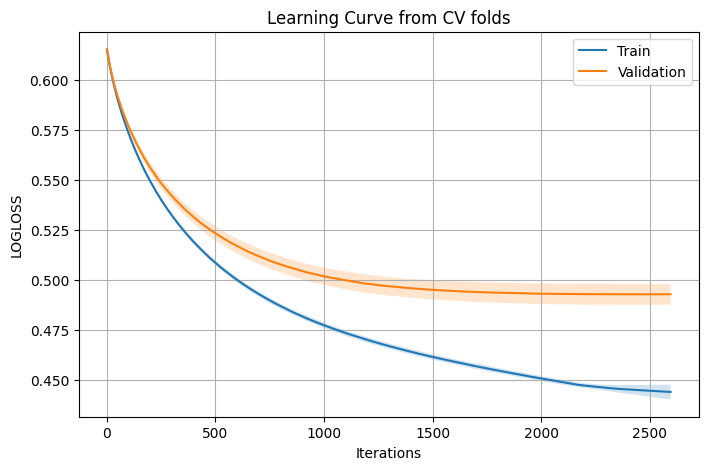


Training final model on full training data...
[0]	train-logloss:0.61537
[100]	train-logloss:0.57407
[200]	train-logloss:0.55070
[300]	train-logloss:0.53402
[400]	train-logloss:0.52133
[500]	train-logloss:0.51122
[600]	train-logloss:0.50299
[700]	train-logloss:0.49620
[800]	train-logloss:0.49048
[900]	train-logloss:0.48562
[999]	train-logloss:0.48143
---------------- Train Set --------------------
     Metric     Value
0   ROC AUC  0.820026
1  Log Loss  0.481433
2  Accuracy  0.766833
The best mean CV score across all trials: 0.792131017677611
OOF auc: 0.79213
Saved model → /home/ismail/x42/outputs/experiments/20260421-224523_xgb_CVScore0.7921_exp_20260421-2245_learning_rate0.011745739208656958_max_depth3/model.pkl
Saved params → /home/ismail/x42/outputs/experiments/20260421-224523_xgb_CVScore0.7921_exp_20260421-2245_learning_rate0.011745739208656958_max_depth3/params.json
Saved metrics → /home/ismail/x42/outputs/experiments/20260421-224523_xgb_CVScore0.7921_exp_20260421-2245_learning_r

AttributeError: 'NoneType' object has no attribute 'get'

In [ ]:


# -------------------------------
# Run Optuna study
# -------------------------------
start = time.time()

study = run_optuna(objective, cfg, use_median_pruner=False, warmup_steps=2)
train_time = time.time() - start

fold_evals = study.best_trial.user_attrs['fold_evals']
plot_learning_curve(fold_evals, metric_name=cfg.LIB_PARAMS["xgboost"]["eval_metric"])
oof_preds = study.best_trial.user_attrs['oof_preds']

# -------------------------------
# Train final XGBoost model
# -------------------------------
print("\nTraining final model on full training data...")
best_params = study.best_params.copy()
best_params.update({
    'objective': cfg.LIB_PARAMS["xgboost"]["objective"],
    'eval_metric': cfg.LIB_PARAMS["xgboost"]["eval_metric"],
    'verbosity': 0
})
if cfg.TASK.lower() == "multiclass":
    best_params['num_class'] = num_classes

best_iteration = study.best_trial.user_attrs.get("best_iteration", cfg.NUM_BOOST_ROUND)

final_model = train_xgb_final(X_train, y_train_numeric, best_params, best_iteration)



# -------------------------------
# Evaluate on train set
# -------------------------------
print("---------------- Train Set --------------------")

metrics_df, y_pred_train_class = evaluate_model(
    y_train_numeric,
    final_model.predict(xgb.DMatrix(X_train), iteration_range=(0, best_iteration)),
    task=cfg.TASK
)
print(metrics_df)
print("The best mean CV score across all trials:", study.best_value)

if cfg.TASK.lower() == "binary":
    oof_pred_class = (oof_preds >= 0.5).astype(int)
else:
    oof_pred_class = np.argmax(oof_preds, axis=1)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,  # keep as probabilities
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)

print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")





# -------------------------------
# Evaluate on test set
# -------------------------------
pred_test = final_model.predict(xgb.DMatrix(X_test), iteration_range=(0, best_iteration))
y_pred_class = (pred_test >= 0.5).astype(int) if cfg.TASK=='binary' else pred_test.argmax(axis=1)

if X_test is not None and y_test is not None:
    roc_auc_test = roc_auc_score(y_test, pred_test) if cfg.TASK=='binary' else roc_auc_score(y_test, pred_test, multi_class='ovr')
    logloss_test = log_loss(y_test, pred_test)
    accuracy_test = accuracy_score(y_test, y_pred_class)
    print("\n--- Test set performance ---")
    print(f"Test ROC AUC: {roc_auc_test:.5f}")
    print(f"Test Log Loss: {logloss_test:.5f}")
    print(f"Test Accuracy: {accuracy_test:.5f}")





# ----------------------------------
# Postprocessing
# ----------------------------------
from src.postprocessing_utils import optimize_postprocessing, apply_postprocessing

# -------------------------------
# Run optimization & show OOF accuracy
# -------------------------------
postprocessing_params = {}
if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]

    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=200,
        seeds=pp_seeds
    )

    # Apply best post-processing to OOF predictions
    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)
    oof_pred_class_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK)


    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,  # keep as probabilities
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")

    postprocessing_params = {
        "best_params": pp_best_params,
        "best_seed": pp_best_seed,
        "best_score": pp_best_score,
        "oof_pred_class_opt": oof_pred_class_opt,
        "oof_pred_opt": oof_pred_opt,
        "oof_acc_opt": oof_acc_opt,
        "kaggle_eval": KAGGLE_EVAL  # or "roc_auc"
    }




# ----------------------------------
# ExperimentTracker
# ----------------------------------

from src.experiment_tracker import ExperimentTracker

tracker = ExperimentTracker()
exp_dir = tracker.run_experiment(
    model_name="xgb",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=study.best_value,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params= postprocessing_params,
    use_postprocessing= USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label = int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
    
)


gc.collect()





### Genetic search

In [ ]:
import xgboost as xgb
import numpy as np
import time
import gc

from sklearn.metrics import log_loss, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

from deap import base, creator, tools, algorithms


# =========================
# BASIC SETUP
# =========================
num_classes = len(np.unique(y_train_numeric))
metric_name = cfg.LIB_PARAMS["xgboost"]["eval_metric"]
maximize_metric = cfg.MAXIMIZE_METRIC

print(f"Number of classes: {num_classes}")


# =========================
# SEARCH SPACE (same logic as LGBM)
# =========================
param_grid = {
    'learning_rate': (0.01, 0.15),
    'max_depth': (3, 12),
    'min_child_weight': (1e-3, 10.0),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0),
    'gamma': (0.0, 0.5),
    'reg_alpha': (0.0, 0.5),
    'reg_lambda': (0.0, 0.5)
}


# =========================
# SAFE PARAM CLIP (FIX)
# =========================
def clip_params(params):
    params["max_depth"] = int(np.clip(round(params["max_depth"]), 3, 12))
    params["min_child_weight"] = max(1.0, float(params["min_child_weight"]))

    for k in ['learning_rate','subsample','colsample_bytree','gamma','reg_alpha','reg_lambda']:
        params[k] = float(np.clip(params[k], *param_grid[k]))

    return params


# =========================
# DEAP SETUP
# =========================
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

for i, (low, high) in enumerate(param_grid.values()):
    toolbox.register(f"attr_{i}", np.random.uniform, low, high)

toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    [toolbox.__getattribute__(f"attr_{i}") for i in range(len(param_grid))],
    n=1
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)


# =========================
# SAFE MUTATION (FIX)
# =========================
def safe_mutation(individual):
    tools.mutGaussian(individual, mu=0, sigma=0.05, indpb=0.2)
    for i, (k, (low, high)) in enumerate(param_grid.items()):
        individual[i] = np.clip(individual[i], low, high)
    return (individual,)


# =========================
# OBJECTIVE
# =========================
def objective(individual):

    params = dict(zip(param_grid.keys(), individual))
    params = clip_params(params)

    param = {
        **params,
        "objective": cfg.LIB_PARAMS["xgboost"]["objective"],
        "eval_metric": metric_name,
        "booster": "gbtree",
        "tree_method": "hist",
        "seed": getattr(cfg, "RANDOM_STATE", 42),
        "verbosity": 0
    }

    if num_classes > 2:
        param["num_class"] = num_classes

    oof_preds = (
        np.zeros((len(X_train), num_classes))
        if num_classes > 2
        else np.zeros(len(X_train))
    )

    fold_scores = []
    fold_iters = []
    eval_history = []

    for train_idx, valid_idx in folds:

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train_numeric[train_idx], y_train_numeric[valid_idx]

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dvalid = xgb.DMatrix(X_val, label=y_val)

        evals_result = {}

        model = xgb.train(
            params=param,
            dtrain=dtrain,
            num_boost_round=1000,
            evals=[(dtrain, "train"), (dvalid, "valid")],
            early_stopping_rounds=50,
            evals_result=evals_result,
            verbose_eval=False
        )

        pred_val = model.predict(dvalid, iteration_range=(0, model.best_iteration))
        oof_preds[valid_idx] = pred_val

        if maximize_metric:
            if num_classes > 2:
                score = roc_auc_score(y_val, pred_val, multi_class="ovr")
            else:
                score = roc_auc_score(y_val, pred_val)
        else:
            score = log_loss(y_val, pred_val)

        fold_scores.append(score)
        fold_iters.append(model.best_iteration)
        eval_history.append(evals_result)

        del model, dtrain, dvalid
        gc.collect()

    if maximize_metric:
        mean_score = (
            roc_auc_score(y_train_numeric, oof_preds)
            if num_classes == 2
            else roc_auc_score(y_train_numeric, oof_preds, multi_class="ovr")
        )
        fitness = mean_score
    else:
        mean_score = log_loss(y_train_numeric, oof_preds)
        fitness = -mean_score

    best_iter = int(np.mean(fold_iters))

    individual.oof_preds = oof_preds
    individual.best_iteration = best_iter
    individual.params = param
    individual.mean_score = mean_score

    return (fitness,)


# =========================
# GA OPERATORS
# =========================
toolbox.register("evaluate", objective)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", safe_mutation)
toolbox.register("select", tools.selTournament, tournsize=3)


# =========================
# RUN GA
# =========================
pop = toolbox.population(n=20)
NGEN = 5
CXPB, MUTPB = 0.7, 0.3

for gen in range(NGEN):
    offspring = algorithms.varAnd(pop, toolbox, cxpb=CXPB, mutpb=MUTPB)

    fits = list(map(toolbox.evaluate, offspring))

    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit

    pop = toolbox.select(offspring, k=len(pop))

    best = tools.selBest(pop, 1)[0]
    print(f"Gen {gen+1} | Best score: {best.mean_score:.5f}")


# =========================
# BEST MODEL
# =========================
best_trial = tools.selBest(pop, 1)[0]

oof_preds = best_trial.oof_preds
best_iteration = best_trial.best_iteration
best_params = best_trial.params
best_score = best_trial.mean_score


# =========================
# FINAL TRAIN
# =========================
print("\nTraining final XGBoost model...")

start = time.time()

dtrain_full = xgb.DMatrix(X_train, label=y_train_numeric)

final_model = xgb.train(
    params=best_params,
    dtrain=dtrain_full,
    num_boost_round=best_iteration
)

train_time = time.time() - start


# =========================
# EVALUATION (same as LGBM)
# =========================
print("---------------- Train Set --------------------")

train_pred = final_model.predict(dtrain_full)

metrics_df, y_pred_train_class = evaluate_model(
    y_train_numeric,
    train_pred,
    task=cfg.TASK
)

print(metrics_df)
print("Best CV score:", best_score)

oof_score = evaluate_metric(
    y_true=y_train_numeric,
    y_input=oof_preds,
    task=TASK,
    kaggle_eval=KAGGLE_EVAL
)

print(f"OOF {KAGGLE_EVAL}: {oof_score:.5f}")


# =========================
# POSTPROCESSING (UNCHANGED)
# =========================
postprocessing_params = {}

if USE_POSTPROCESSING:
    pp_seeds = [RANDOM_STATE, 2026, 1234, 9999]

    pp_best_params, pp_best_seed, pp_best_score = optimize_postprocessing(
        oof_preds,
        y_train_numeric,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL,
        n_trials=200,
        seeds=pp_seeds
    )

    oof_pred_opt = apply_postprocessing(oof_preds, pp_best_params, task=TASK, return_proba=True)

    oof_acc_opt = evaluate_metric(
        y_true=y_train_numeric,
        y_input=oof_pred_opt,
        task=TASK,
        kaggle_eval=KAGGLE_EVAL
    )

    print(f"OOF {KAGGLE_EVAL} after post-processing: {oof_acc_opt:.5f}")


# =========================
# TRACKER (UNCHANGED)
# =========================
tracker = ExperimentTracker()

exp_dir = tracker.run_experiment(
    model_name="xgboost_genetic",
    final_model=final_model,
    X_train=X_train,
    y_train=y_train_numeric,
    X_test=X_test,
    best_params=best_params,
    best_score=best_score,
    metrics_df=metrics_df,
    train_time=train_time,
    oof_preds=oof_preds,
    task=TASK,
    postprocessing_params=postprocessing_params,
    use_postprocessing=USE_POSTPROCESSING,
    test_ids=test_ids,
    id_col=ID,
    target_col=TARGET,
    int_to_label=int_to_label,
    sample_submission_path=SUB_PATH,
    submit_proba=SUBMIT_PROBABILITIES
)

gc.collect()

Number of classes: 2
Gen 1 | Best score: 0.78340
Gen 2 | Best score: 0.78692
Gen 3 | Best score: 0.78692
Gen 4 | Best score: 0.78779
Gen 5 | Best score: 0.78790

Training final XGBoost model...
---------------- Train Set --------------------
     Metric     Value
0   ROC AUC  0.848720
1  Log Loss  0.447272
2  Accuracy  0.789600
Best CV score: 0.7879023926520302
OOF auc: 0.78790
Saved model → /home/ismail/x42/outputs/experiments/20260421-231556_xgboost_genetic_CVScore0.7879_exp_20260421-2315_learning_rate0.032659700484495666_max_depth3/model.pkl
Saved params → /home/ismail/x42/outputs/experiments/20260421-231556_xgboost_genetic_CVScore0.7879_exp_20260421-2315_learning_rate0.032659700484495666_max_depth3/params.json
Saved metrics → /home/ismail/x42/outputs/experiments/20260421-231556_xgboost_genetic_CVScore0.7879_exp_20260421-2315_learning_rate0.032659700484495666_max_depth3/metrics.json
Saved training time → /home/ismail/x42/outputs/experiments/20260421-231556_xgboost_genetic_CVScore0.7

AttributeError: 'NoneType' object has no attribute 'get'

In [6]:
import optuna.visualization as vis



# Slice plot for individual params
vis.plot_slice(study)


In [7]:
vis.plot_param_importances(study)


In [8]:
# Parallel coordinate plot of top trials
vis.plot_parallel_coordinate(study)

In [9]:
vis.plot_contour(study)

[W 2026-01-28 17:57:08,571] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,573] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,574] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,575] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,575] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,576] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,576] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,577] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,577] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,578] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,578] Param random_state unique value length is less than 2.
[W 2026-01-28 17:57:08,578] Param random_state unique value length is less than 2.
[W 2

In [10]:
vis.plot_optimization_history(study)

In [11]:
vis.plot_intermediate_values(study)

In [12]:
import shap
import numpy as np
X_shap = X_train.sample(1000, random_state=42)  # reduce if slow
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    class_names=[f"Class {i}" for i in range(len(shap_values))]
)

ValueError: could not convert string to float: '[6.2333894E-1]'